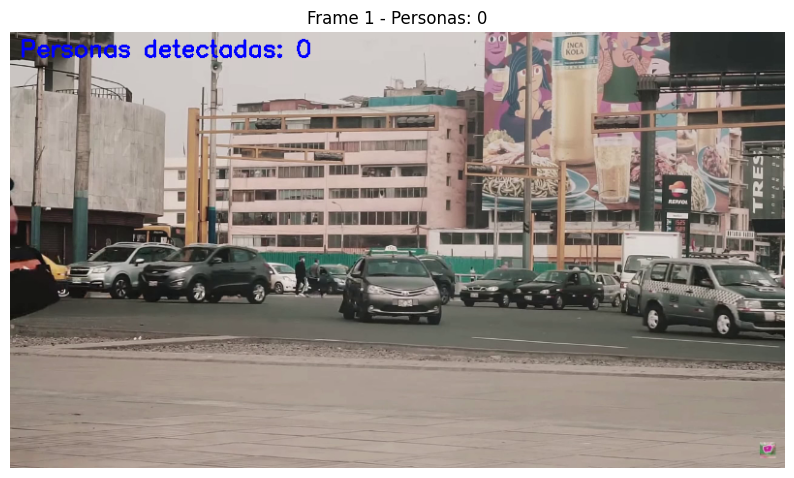

In [ ]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

cap = cv2.VideoCapture('/content/personas.mp4')

if not cap.isOpened():
    print("Error: Could not open video file.")
else:
    total_personas = 0
    frame_count = 0
    frame_limit = 6806

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter('deteccion_de_personas.mp4', fourcc, 30.0, (800, int(cap.get(4) * 800 / cap.get(3))))

    while cap.isOpened() and frame_count < frame_limit:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % 30 != 0:
            frame_count += 1
            continue

        frame = cv2.resize(frame, (800, int(frame.shape[0] * 800 / frame.shape[1])))

        (personas, _) = hog.detectMultiScale(frame,
                                             winStride=(8, 8),
                                             padding=(8, 8),
                                             scale=1.05)

        for (x, y, w, h) in personas:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        total_personas += len(personas)

        cv2.putText(frame, f'Personas detectadas: {len(personas)}', (10, 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(frame_rgb)
        plt.axis('off')
        plt.title(f'Frame {frame_count + 1} - Personas: {len(personas)}')
        display(plt.gcf())
        plt.close()
        clear_output(wait=True)

        frame_count += 1

    cap.release()
    out.release()